# Robomimic Residual Recovery Policy Training

Train a residual policy that predicts a short horizon of corrective actions
conditioned on recent state/action history from perturbed trajectories.

In [1]:
import os
import sys
import h5py
import torch
import numpy as np
import random
from tqdm import tqdm
from pathlib import Path

# Ensure local package importable (adjust path if needed)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from a2l_pr.models import ResidualRecoveryPolicy

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


In [2]:
# Lightweight trajectory loader similar to other notebooks
def load_robomimic_trajectory(hdf5_path, demo_key='demo_0'):
    f = h5py.File(hdf5_path, 'r')
    demo_grp = f['data'][demo_key]
    obs_grp = demo_grp['obs']
    trajectory = {'actions': demo_grp['actions'][:], 'observations': {}}
    for key in obs_grp.keys():
        trajectory['observations'][key] = obs_grp[key][:]
    f.close()
    return trajectory


def _traj_length(traj):
    return len(traj['actions'])

In [3]:
# Edit this path if your dataset is located elsewhere
robomimic_hdf5_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'robomimic', 'robomimic', 'datasets', 'square', 'ph', 'low_dim_v15.hdf5'))
print('Dataset path:', robomimic_hdf5_path)

Dataset path: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/datasets/square/ph/low_dim_v15.hdf5


## Build residual training records

Each record contains:
- `past_states` (HISTORY steps from the perturbed trajectory),
- `past_actions` (HISTORY steps from the perturbed trajectory),
- `target_residuals` (original_actions - perturbed_actions for the next HORIZON steps).

In [4]:
from a2l_pr.adapters.robomimic import RobomimicAdapter
from a2l_pr.perturbations.generator import PerturbationGenerator, PerturbationType

adapter = RobomimicAdapter()
generator = PerturbationGenerator()

HISTORY = 12
HORIZON = 30

def generate_residual_records(demo_keys, hdf5_path, desc='Processing'):
    records = []
    for demo_key in tqdm(demo_keys, desc=desc):
        raw_traj = load_robomimic_trajectory(hdf5_path, demo_key=demo_key)
        traj = adapter.load(raw_traj)
        traj_len = _traj_length(traj)

        # try several perturbation types per trajectory
        perturbation_types = [PerturbationType.UNDERREACH_IDLE, PerturbationType.PREMATURE_CLOSE, PerturbationType.LATERAL_DRIFT, PerturbationType.PREMATURE_OPEN]
        for p_type in perturbation_types:
            res = generator.apply_perturbation(traj, p_type, severity=0.75)
            if res is None:
                continue
            pert = res.perturbed_trajectory
            perturb_start, perturb_end = res.perturbation_window

            # select history that ends before the perturbation onset
            hist_end = max(0, int(perturb_start) - 1)
            hist_start = max(0, hist_end - HISTORY + 1)

            past_states = []
            past_actions = []
            for t in range(hist_start, hist_end + 1):
                st = []
                for k in ['robot0_eef_pos','robot0_eef_quat','robot0_gripper_qpos','robot0_joint_pos','robot0_joint_vel']:
                    if k in pert['observations'] and t < len(pert['observations'][k]):
                        st.append(np.asarray(pert['observations'][k][t]).reshape(-1))
                if len(st) == 0:
                    continue
                past_states.append(np.concatenate(st).astype(np.float32))
                past_actions.append(np.asarray(pert['actions'][t]).reshape(-1).astype(np.float32))

            if len(past_states) < HISTORY:
                continue

            past_states = np.stack(past_states[-HISTORY:], axis=0)
            past_actions = np.stack(past_actions[-HISTORY:], axis=0)

            # compute target residuals for the next HORIZON steps (orig - pert)
            target_res = []
            for t in range(int(perturb_start), int(perturb_start) + HORIZON):
                if t < len(traj['actions']) and t < len(pert['actions']):
                    orig_a = np.asarray(traj['actions'][t]).reshape(-1).astype(np.float32)
                    pert_a = np.asarray(pert['actions'][t]).reshape(-1).astype(np.float32)
                    target_res.append((orig_a - pert_a))
                else:
                    target_res.append(np.zeros_like(pert['actions'][0], dtype=np.float32))

            target_res = np.stack(target_res, axis=0)

            records.append({
                'past_states': past_states,
                'past_actions': past_actions,
                'target_residuals': target_res,
            })

    return records

In [5]:
# Build a small training/validation split for quick iteration
f = h5py.File(robomimic_hdf5_path, 'r')
all_demos = list(f['data'].keys())
f.close()
random.shuffle(all_demos)
train_keys = all_demos[:int(0.8 * len(all_demos))]
val_keys = all_demos[int(0.8 * len(all_demos)):int(0.9 * len(all_demos))]

train_records = generate_residual_records(train_keys, robomimic_hdf5_path, desc='Train')
val_records = generate_residual_records(val_keys, robomimic_hdf5_path, desc='Val')

print('Train samples:', len(train_records), 'Val samples:', len(val_records))

Train:   0%|          | 0/160 [00:00<?, ?it/s]

Val: 100%|██████████| 20/20 [00:00<00:00, 159.91it/s]

Train samples: 407 Val samples: 52


In [6]:
from torch.utils.data import Dataset, DataLoader

class ResidualRecoveryDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        return {
            'past_states': torch.tensor(r['past_states']).float(),
            'past_actions': torch.tensor(r['past_actions']).float(),
            'target_residuals': torch.tensor(r['target_residuals']).float(),
        }

train_ds = ResidualRecoveryDataset(train_records)
val_ds = ResidualRecoveryDataset(val_records)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)


In [7]:
# Instantiate model using first sample dims
if len(train_ds) == 0:
    raise RuntimeError('No training samples - adjust dataset path or perturbation parameters')
sample = train_ds[0]
state_dim = int(sample['past_states'].shape[-1])
action_dim = int(sample['past_actions'].shape[-1])
print('state_dim', state_dim, 'action_dim', action_dim)

model = ResidualRecoveryPolicy(state_dim=state_dim, action_dim=action_dim, history_length=HISTORY, prediction_horizon=HORIZON)
model.to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = torch.nn.MSELoss()


state_dim 23 action_dim 7


In [8]:
# Lightweight training loop (MSE on residual sequence)
EPOCHS = 8
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f'Train {epoch}'):
        ps = batch['past_states'].to(device)
        pa = batch['past_actions'].to(device)
        tgt = batch['target_residuals'].to(device)

        pred = model(ps, pa)  # (B, HORIZON, action_dim)

        loss = criterion(pred, tgt)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        train_loss += loss.item() * ps.shape[0]

    train_loss = train_loss / len(train_ds)

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            ps = batch['past_states'].to(device)
            pa = batch['past_actions'].to(device)
            tgt = batch['target_residuals'].to(device)
            pred = model(ps, pa)
            val_loss += criterion(pred, tgt).item() * ps.shape[0]
    val_loss = val_loss / len(val_ds) if len(val_ds) > 0 else float('nan')

    print(f'Epoch {epoch} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

# Save final model
torch.save(model.state_dict(), 'residual_recovery_policy.pth')

Train 1: 100%|██████████| 13/13 [00:00<00:00, 53.06it/s]


Epoch 1 | Train Loss: 0.083149 | Val Loss: 0.073747


Train 2: 100%|██████████| 13/13 [00:00<00:00, 128.38it/s]


Epoch 2 | Train Loss: 0.076959 | Val Loss: 0.072866


Train 3: 100%|██████████| 13/13 [00:00<00:00, 119.75it/s]


...

Epoch 6 | Train Loss: 0.050433 | Val Loss: 0.046246


Train 7: 100%|██████████| 13/13 [00:00<00:00, 121.32it/s]


Epoch 7 | Train Loss: 0.047260 | Val Loss: 0.042894


Train 8: 100%|██████████| 13/13 [00:00<00:00, 121.28it/s]

Epoch 8 | Train Loss: 0.044355 | Val Loss: 0.043320


## Notes and next steps

- Tune `HISTORY` and `HORIZON` to match the real control timestep and planner horizon.
- Consider smoothing/clamping residuals before applying to the simulator for safety.
- Optionally condition the encoder on images by integrating a vision branch into `ResidualRecoveryPolicy`.

## Residual Recovery Visualizations

The cells below mirror the visualization style in the full training notebook:
- 3D trajectory comparison (original vs perturbed vs recovered)
- Optional simulation videos (if `robomimic` rendering utilities are available)


In [9]:
import matplotlib.pyplot as plt
from base64 import b64encode
from IPython.display import HTML, display
import imageio

from a2l_pr.utils.trajectory import TrajectoryAnalyzer

try:
    import robomimic.utils.obs_utils as ObsUtils
    import robomimic.utils.env_utils as EnvUtils
    import robomimic.utils.file_utils as FileUtils
    HAS_ROBOMIMIC = True
except ImportError:
    print('robomimic not found in environment, simulation videos will be skipped.')
    HAS_ROBOMIMIC = False

I0000 00:00:1778541924.914282  823533 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778541924.938050  823533 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778541925.564130  823533 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [10]:
def _build_low_dim_state_vector(traj_dict, t):
    parts = []
    for k in ['robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_joint_pos', 'robot0_joint_vel']:
        if k in traj_dict['observations'] and t < len(traj_dict['observations'][k]):
            parts.append(np.asarray(traj_dict['observations'][k][t]).reshape(-1))
    if len(parts) == 0:
        return None
    return np.concatenate(parts).astype(np.float32)


def _predict_recovered_actions(original_traj, perturbed_traj, perturb_start, history=HISTORY, horizon=HORIZON):
    action_dim_local = perturbed_traj['actions'].shape[-1]
    traj_len = len(perturbed_traj['actions'])

    hist_end = max(0, int(perturb_start) - 1)
    hist_start = max(0, hist_end - history + 1)

    past_states = []
    past_actions = []
    for t in range(hist_start, hist_end + 1):
        s_t = _build_low_dim_state_vector(perturbed_traj, t)
        if s_t is None:
            continue
        past_states.append(s_t)
        past_actions.append(np.asarray(perturbed_traj['actions'][t]).reshape(-1).astype(np.float32))

    if len(past_states) < history:
        return np.asarray(perturbed_traj['actions']).copy(), None

    past_states = np.stack(past_states[-history:], axis=0)
    past_actions = np.stack(past_actions[-history:], axis=0)

    with torch.no_grad():
        ps = torch.tensor(past_states).float().unsqueeze(0).to(device)
        pa = torch.tensor(past_actions).float().unsqueeze(0).to(device)
        pred_res = model(ps, pa, prediction_horizon=horizon)[0].cpu().numpy()

    recovered_actions = np.asarray(perturbed_traj['actions']).copy()
    start = int(perturb_start)
    end = min(traj_len, start + horizon)
    if end > start:
        residual_slice = pred_res[:(end - start)]
        recovered_actions[start:end] = recovered_actions[start:end] + np.clip(residual_slice, -1.0, 1.0)

    return recovered_actions, pred_res


def _build_recovered_trajectory_dict(perturbed_traj, recovered_actions):
    recovered = {
        'actions': recovered_actions,
        'observations': perturbed_traj.get('observations', {})
    }
    if 'metadata' in perturbed_traj:
        recovered['metadata'] = perturbed_traj['metadata']
    return recovered


def visualize_trajectory_comparison_3d(original, perturbed, recovered, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    orig_pos = TrajectoryAnalyzer(original).get_ee_position()
    pert_pos = TrajectoryAnalyzer(perturbed).get_ee_position()
    rec_pos = TrajectoryAnalyzer(recovered).get_ee_position()

    if len(orig_pos) > 0:
        ax.plot(orig_pos[:, 0], orig_pos[:, 1], orig_pos[:, 2], label='Original', color='blue', alpha=0.7, linestyle='--')
    if len(pert_pos) > 0:
        ax.plot(pert_pos[:, 0], pert_pos[:, 1], pert_pos[:, 2], label='Perturbed', color='red', alpha=0.6)
    if len(rec_pos) > 0:
        ax.plot(rec_pos[:, 0], rec_pos[:, 1], rec_pos[:, 2], label='Recovered', color='green', alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

Visualization demo: demo_85 | perturbations built: ['UNDERREACH_IDLE', 'PREMATURE_CLOSE', 'LATERAL_DRIFT', 'PREMATURE_OPEN']


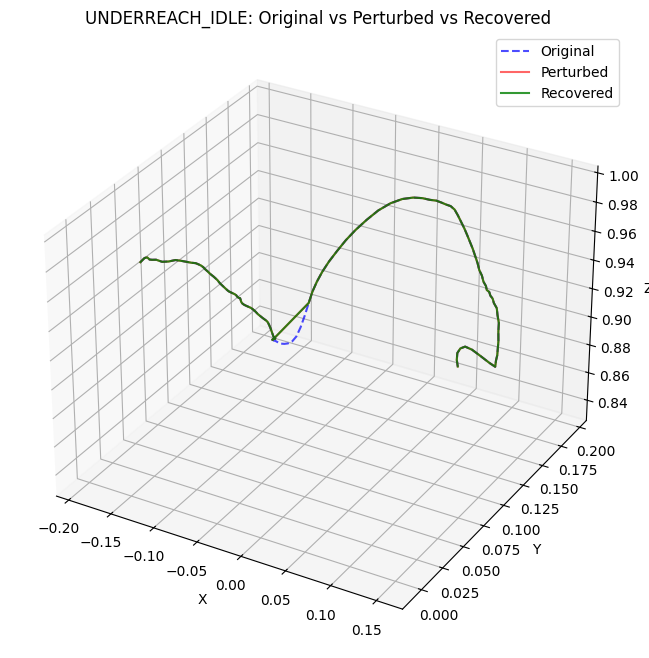

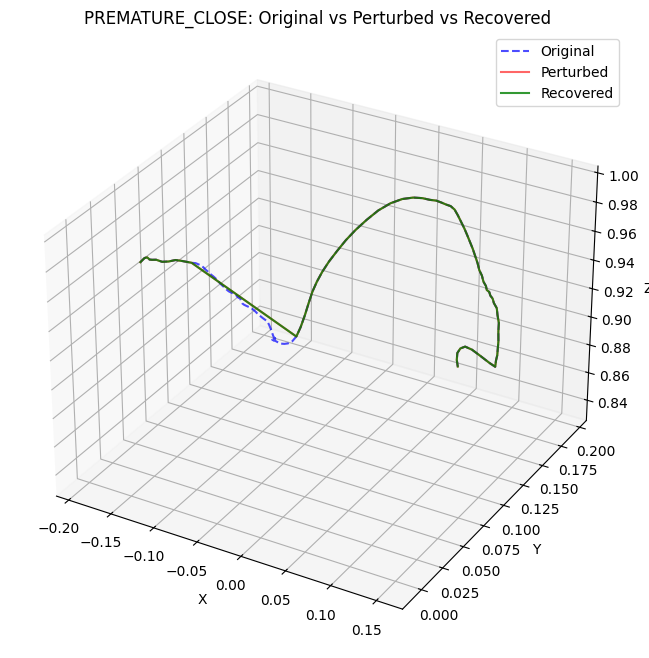

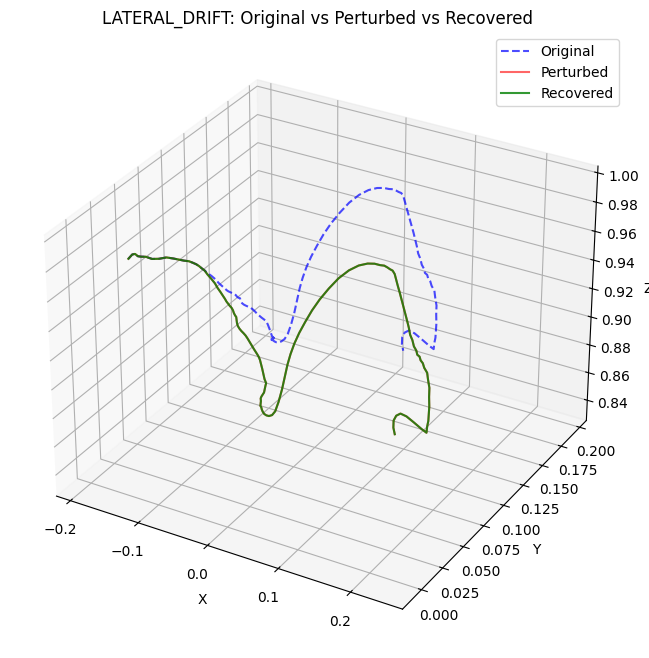

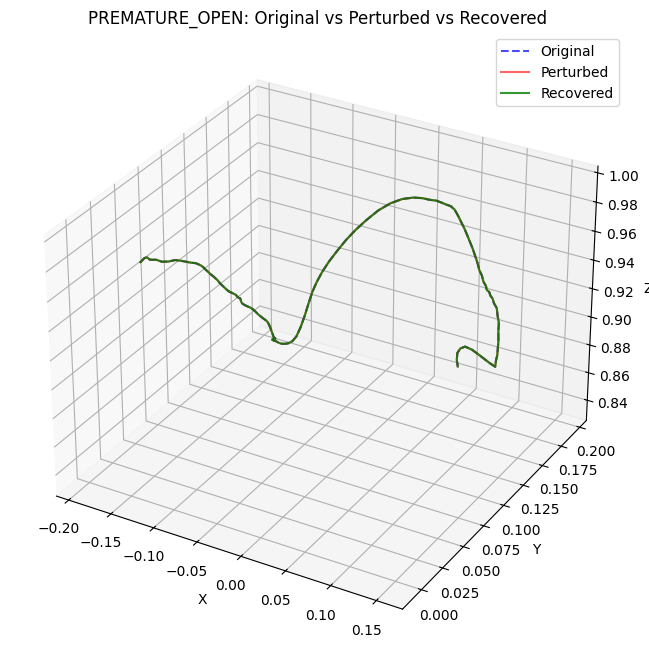

In [11]:
# Build one held-out visualization trajectory and compare perturbations
if len(val_keys) == 0:
    raise RuntimeError('No validation demos available for visualization')

vis_demo_key = val_keys[0]
raw_vis = load_robomimic_trajectory(robomimic_hdf5_path, demo_key=vis_demo_key)
orig_vis = adapter.load(raw_vis)

vis_perturbation_types = [
    PerturbationType.UNDERREACH_IDLE,
    PerturbationType.PREMATURE_CLOSE,
    PerturbationType.LATERAL_DRIFT,
    PerturbationType.PREMATURE_OPEN,
]

vis_results = {}
for p_type in vis_perturbation_types:
    res = generator.apply_perturbation(orig_vis, p_type, severity=0.75)
    if res is None:
        continue

    pert_actions = np.asarray(res.perturbed_trajectory['actions'])
    recovered_actions, pred_residuals = _predict_recovered_actions(
        original_traj=orig_vis,
        perturbed_traj=res.perturbed_trajectory,
        perturb_start=res.perturbation_window[0],
        history=HISTORY,
        horizon=HORIZON,
    )
    recovered_traj = _build_recovered_trajectory_dict(res.perturbed_trajectory, recovered_actions)

    vis_results[p_type.name] = {
        'perturbed': res.perturbed_trajectory,
        'recovered': recovered_traj,
        'perturbation_window': res.perturbation_window,
        'pred_residuals': pred_residuals,
    }

print(f'Visualization demo: {vis_demo_key} | perturbations built: {list(vis_results.keys())}')

for name, payload in vis_results.items():
    visualize_trajectory_comparison_3d(
        original=orig_vis,
        perturbed=payload['perturbed'],
        recovered=payload['recovered'],
        title=f'{name}: Original vs Perturbed vs Recovered'
    )

In [12]:
def render_trajectory_to_video(traj_dict, dataset_path, ep_name, output_path):
    if not os.path.exists(dataset_path):
        return False
    try:
        dummy_spec = dict(obs=dict(low_dim=['robot0_eef_pos'], rgb=[]))
        ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)
        env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
        env = EnvUtils.create_env_from_metadata(env_meta=env_meta, render=False, render_offscreen=True)

        with h5py.File(dataset_path, 'r') as f:
            states = f[ep_name]['states'][()]
            initial_state = dict(states=states[0])
            if EnvUtils.is_robosuite_env(env_meta):
                initial_state['model'] = f[ep_name].attrs['model_file']

        env.reset_to(initial_state)
        actions = traj_dict.get('actions', [])

        writer = imageio.get_writer(output_path, fps=20)
        for i in range(len(actions)):
            env.step(actions[i])
            if i % 5 == 0:
                frame = env.render(mode='rgb_array', height=256, width=256, camera_name='agentview')
                writer.append_data(frame)
        writer.close()
        return True
    except Exception as e:
        print(f'Render failed: {e}')
        return False


if HAS_ROBOMIMIC and len(vis_results) > 0:
    OUTPUT_DIR = Path(os.getcwd()) / 'output'
    OUTPUT_DIR.mkdir(exist_ok=True)
    ep_name = f"data/{vis_demo_key}"

    html_content = f"<h2>Residual Recovery Video Visualization: {ep_name}</h2><div style='display:flex; flex-direction:row; flex-wrap:wrap; gap:20px;'>"

    for name, payload in vis_results.items():
        perturbed_traj = payload['perturbed']
        recovered_traj = payload['recovered']

        fail_out = str(OUTPUT_DIR / f'residual_{name}_failure.mp4')
        rec_out = str(OUTPUT_DIR / f'residual_{name}_recovery.mp4')

        if render_trajectory_to_video(perturbed_traj, robomimic_hdf5_path, ep_name, fail_out):
            fail_b64 = b64encode(open(fail_out, 'rb').read()).decode('ascii')
            html_content += f"""
            <div style='text-align:center;'>
                <h3>{name} - Failure</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{fail_b64}' type='video/mp4'>
                </video>
            </div>
            """

        if render_trajectory_to_video(recovered_traj, robomimic_hdf5_path, ep_name, rec_out):
            rec_b64 = b64encode(open(rec_out, 'rb').read()).decode('ascii')
            html_content += f"""
            <div style='text-align:center; border:2px solid green;'>
                <h3>{name} - Recovered</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{rec_b64}' type='video/mp4'>
                </video>
            </div>
            """

    html_content += '</div>'
    display(HTML(html_content))
else:
    print('Skipping video rendering (robomimic unavailable or no visualization trajectories).')

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/griffing52/miniconda3/envs/a2l/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7

============= Initialized Observation Utils with Obs Spec =

## Debug: Inspect predicted residuals

The cell below checks if the model is actually predicting non-zero residuals.
If residuals are always near-zero, the model may not have learned recovery yet.

In [13]:
# Inspect actual residuals predicted by model
print("=== Residual Magnitude Inspection ===\n")

for name, payload in vis_results.items():
    pred_res = payload['pred_residuals']
    if pred_res is not None:
        mean_mag = np.mean(np.abs(pred_res))
        max_mag = np.max(np.abs(pred_res))
        min_mag = np.min(np.abs(pred_res))
        print(f"{name}:")
        print(f"  Mean |residual|: {mean_mag:.6f}")
        print(f"  Max  |residual|: {max_mag:.6f}")
        print(f"  Min  |residual|: {min_mag:.6f}")
        print(f"  First 5 residuals: {pred_res[0][:5]}")
        print()
    else:
        print(f"{name}: No residuals predicted (history too short)\n")

=== Residual Magnitude Inspection ===

UNDERREACH_IDLE:
  Mean |residual|: 0.168443
  Max  |residual|: 0.937424
  Min  |residual|: 0.000204
  First 5 residuals: [ 0.459986    0.02319373  0.34018594 -0.09460971  0.03393292]

PREMATURE_CLOSE: No residuals predicted (history too short)

LATERAL_DRIFT:
  Mean |residual|: 0.096635
  Max  |residual|: 0.845397
  Min  |residual|: 0.000106
  First 5 residuals: [-0.09207503  0.1655469  -0.11449769  0.09026325 -0.014489  ]

PREMATURE_OPEN: No residuals predicted (history too short)



## Closed-Loop Recovery Evaluation

The issue with open-loop prediction is that residuals are computed once and applied blindly.
In reality, as we apply actions, the state evolves and our predictions become stale.

**Closed-loop approach**: At each timestep, we re-predict residuals based on the updated state history.
This is more realistic and allows the policy to adapt as it recovers.

In [14]:
def _predict_recovered_actions_closed_loop(original_traj, perturbed_traj, perturb_start, history=HISTORY, horizon=HORIZON):
    """
    Closed-loop recovery: at each step, predict next residual based on current state history.
    This allows the policy to adapt as recovery actions are applied.
    
    Returns:
      recovered_actions: (T, action_dim) corrected action sequence
      applied_residuals: (T, action_dim) actually applied residuals per timestep
    """
    action_dim_local = perturbed_traj['actions'].shape[-1]
    traj_len = len(perturbed_traj['actions'])
    recovered_actions = np.asarray(perturbed_traj['actions']).copy().astype(np.float32)
    applied_residuals = np.zeros_like(recovered_actions)

    # Build initial history (before perturbation)
    hist_end = max(0, int(perturb_start) - 1)
    hist_start = max(0, hist_end - history + 1)
    
    state_history = []
    action_history = []
    for t in range(hist_start, hist_end + 1):
        s_t = _build_low_dim_state_vector(perturbed_traj, t)
        if s_t is None:
            continue
        state_history.append(s_t)
        action_history.append(np.asarray(perturbed_traj['actions'][t]).reshape(-1).astype(np.float32))
    
    if len(state_history) < history:
        # Not enough history; return unchanged
        return recovered_actions, applied_residuals
    
    # Trim to history window
    state_history = state_history[-history:]
    action_history = action_history[-history:]
    
    # Now step forward from perturb_start, predicting residual at each step
    start = int(perturb_start)
    for t_idx in range(start, min(start + horizon, traj_len)):
        # Predict next residual step based on current state/action history
        with torch.no_grad():
            ps = torch.tensor(np.stack(state_history, axis=0)).float().unsqueeze(0).to(device)
            pa = torch.tensor(np.stack(action_history, axis=0)).float().unsqueeze(0).to(device)
            
            # Get only the first-step residual (most confident near-term prediction)
            res_t = model(ps, pa, prediction_horizon=1, return_first_only=True)  # (B, action_dim)
            res_t = res_t[0].cpu().numpy()
        
        # Apply residual (clipped for stability)
        res_t_clipped = np.clip(res_t, -0.5, 0.5)  # Tighter clipping for closed-loop
        recovered_actions[t_idx] = recovered_actions[t_idx] + res_t_clipped
        applied_residuals[t_idx] = res_t_clipped
        
        # Update state/action history for next iteration
        # We simulate that the recovered action was applied and get new observation
        # For closed-loop, we assume the recovered action transitions us to a new state
        # But we don't have a full simulator here, so we approximate by using perturbed obs
        # (This is a limitation; in practice you'd need a model or simulator for true closed-loop)
        
        # For now, we'll use the actual next observation from the perturbed trajectory
        # (In a real scenario, you'd roll forward the action and get new obs)
        if t_idx + 1 < traj_len:
            next_s = _build_low_dim_state_vector(perturbed_traj, t_idx + 1)
            if next_s is not None:
                state_history.append(next_s)
                state_history = state_history[-history:]  # Keep window size
                
                next_a = np.asarray(perturbed_traj['actions'][t_idx + 1]).reshape(-1).astype(np.float32)
                action_history.append(next_a)
                action_history = action_history[-history:]
    
    return recovered_actions, applied_residuals


# Run closed-loop evaluation
print("\n=== Closed-Loop Recovery Evaluation ===\n")
vis_results_closedloop = {}

for p_type in vis_perturbation_types:
    res = generator.apply_perturbation(orig_vis, p_type, severity=0.75)
    if res is None:
        continue

    recovered_actions, applied_res = _predict_recovered_actions_closed_loop(
        original_traj=orig_vis,
        perturbed_traj=res.perturbed_trajectory,
        perturb_start=res.perturbation_window[0],
        history=HISTORY,
        horizon=HORIZON,
    )
    recovered_traj = _build_recovered_trajectory_dict(res.perturbed_trajectory, recovered_actions)
    
    vis_results_closedloop[p_type.name] = {
        'perturbed': res.perturbed_trajectory,
        'recovered': recovered_traj,
        'perturbation_window': res.perturbation_window,
        'applied_residuals': applied_res,
    }
    
    # Print residual statistics
    mean_mag = np.mean(np.abs(applied_res))
    max_mag = np.max(np.abs(applied_res))
    print(f"{p_type.name} (closed-loop):")
    print(f"  Mean |residual| applied: {mean_mag:.6f}")
    print(f"  Max  |residual| applied: {max_mag:.6f}\n")


=== Closed-Loop Recovery Evaluation ===

UNDERREACH_IDLE (closed-loop):
  Mean |residual| applied: 0.028674
  Max  |residual| applied: 0.500000

PREMATURE_CLOSE (closed-loop):
  Mean |residual| applied: 0.000000
  Max  |residual| applied: 0.000000

LATERAL_DRIFT (closed-loop):
  Mean |residual| applied: 0.041339
  Max  |residual| applied: 0.500000

PREMATURE_OPEN (closed-loop):
  Mean |residual| applied: 0.000000
  Max  |residual| applied: 0.000000



## Visualize Closed-Loop Recovery vs Original/Perturbed

Compare the closed-loop recovered trajectories to the original and perturbed:

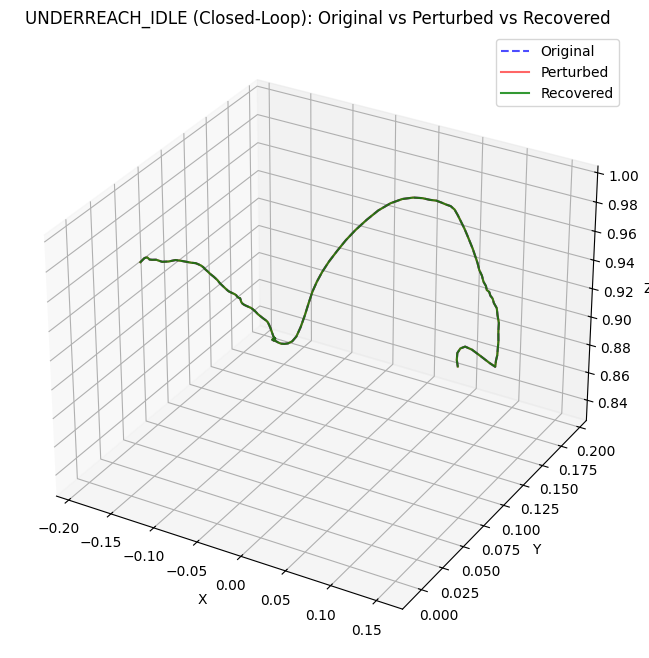

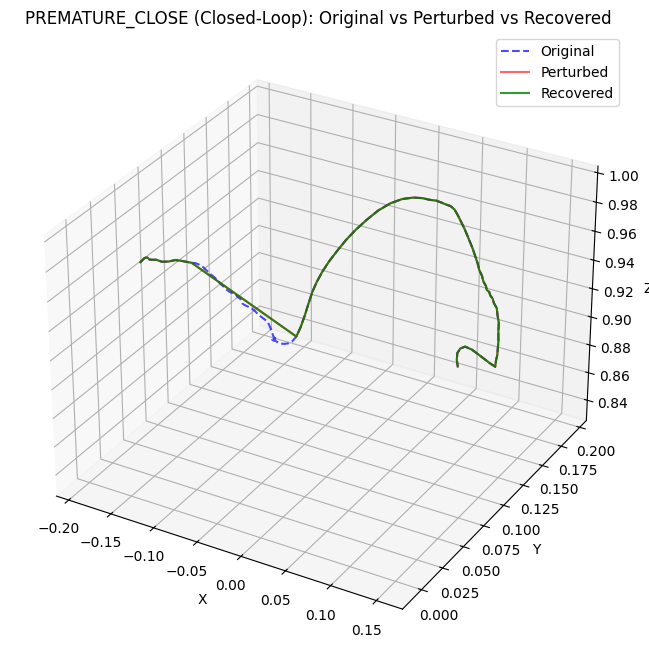

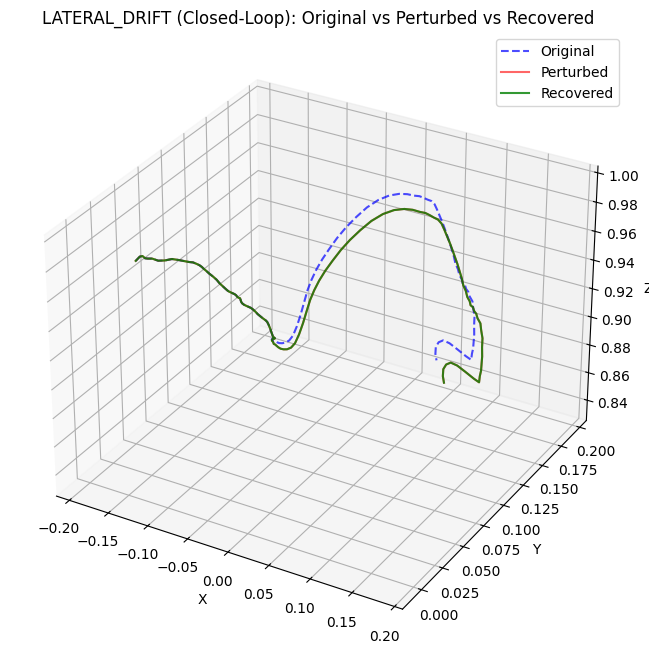

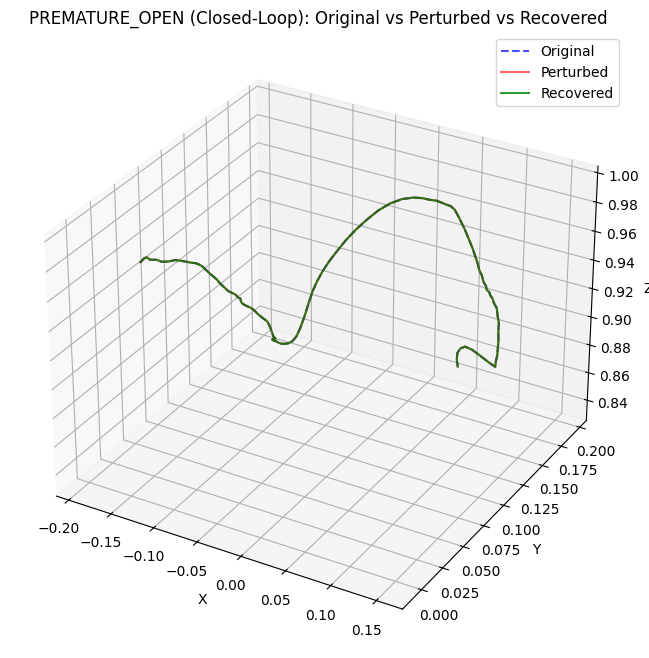

In [15]:
for name, payload in vis_results_closedloop.items():
    visualize_trajectory_comparison_3d(
        original=orig_vis,
        perturbed=payload['perturbed'],
        recovered=payload['recovered'],
        title=f'{name} (Closed-Loop): Original vs Perturbed vs Recovered'
    )

## 2D Trajectory Projection: Seeing the Actual Corrections

Plot EE position in 2D (XY plane) to clearly see how residuals change the trajectory.


=== 2D Trajectory Projections (Closed-Loop) ===

Plotting UNDERREACH_IDLE...


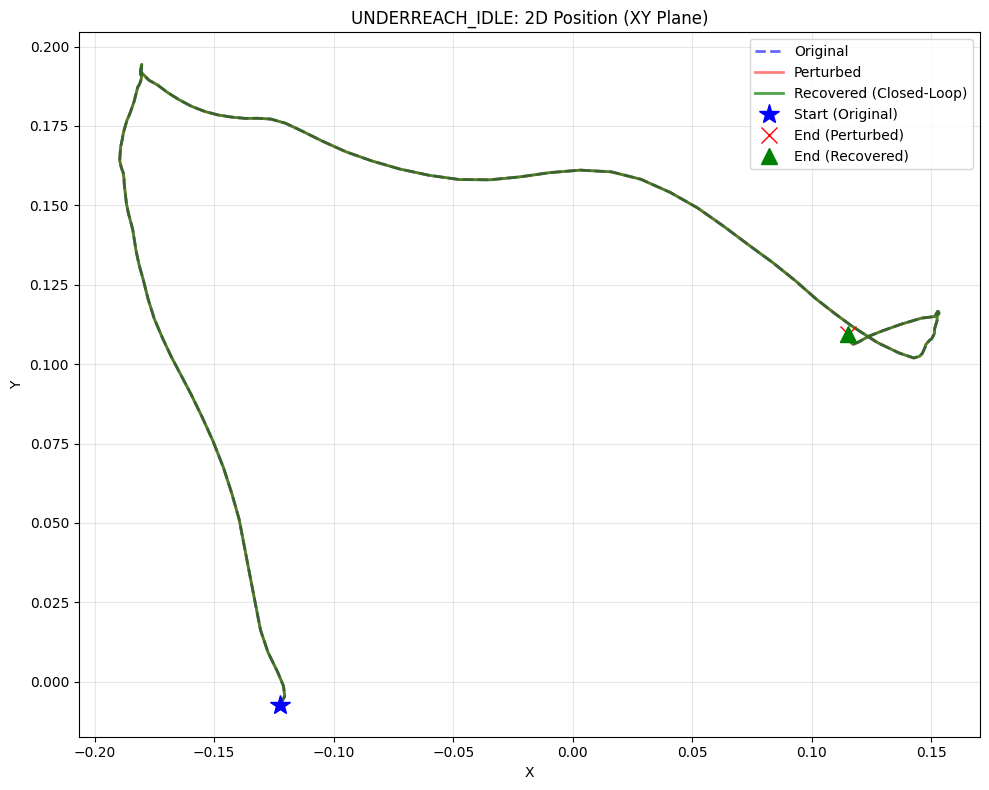

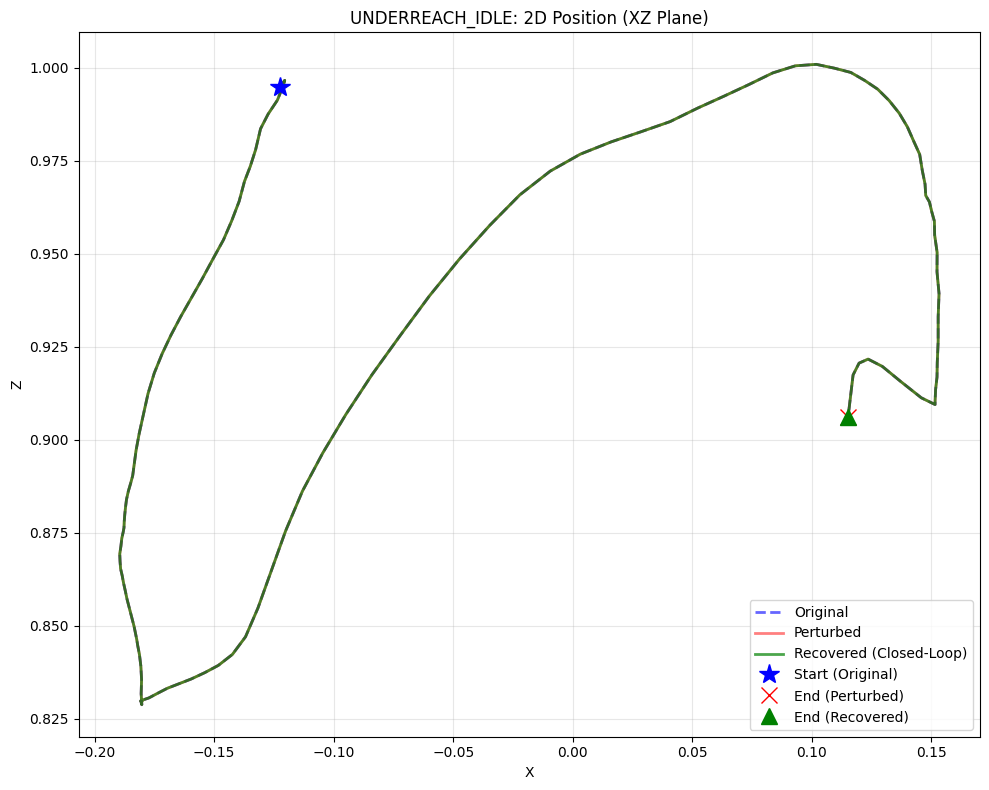

Plotting PREMATURE_CLOSE...


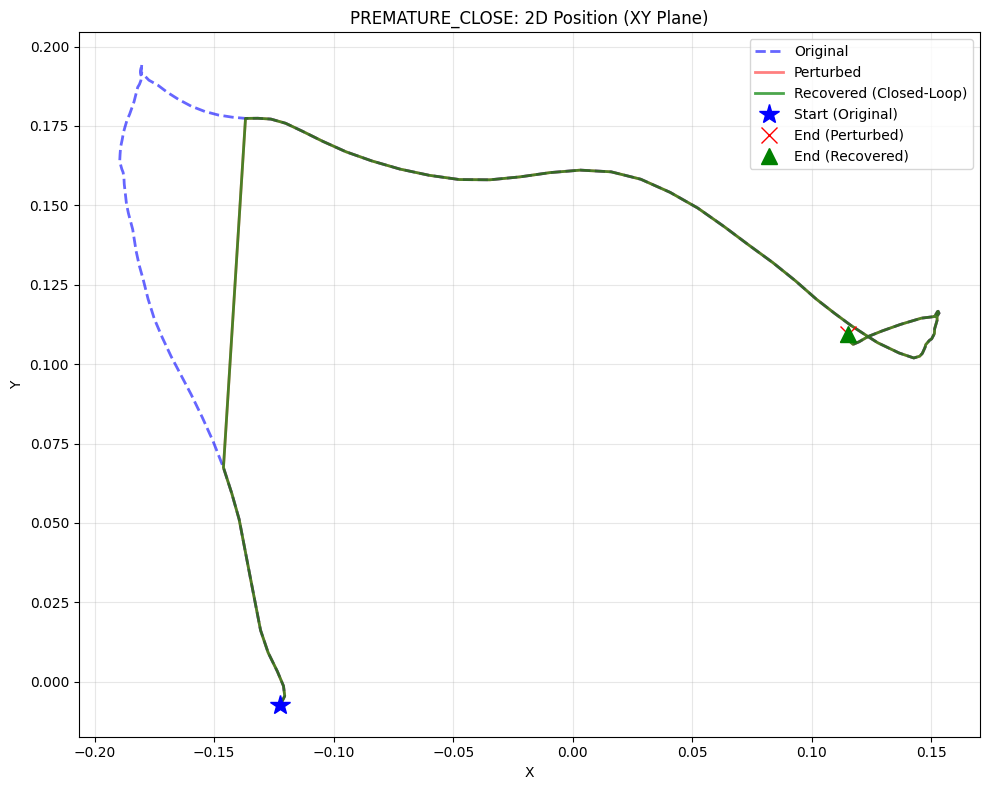

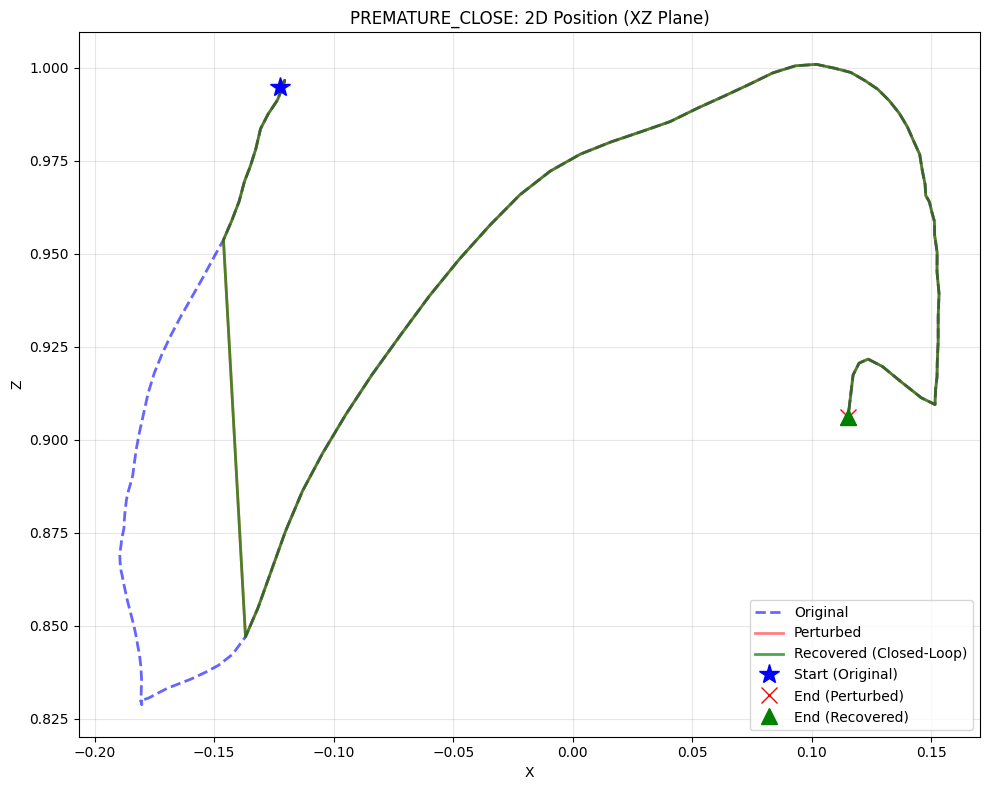

Plotting LATERAL_DRIFT...


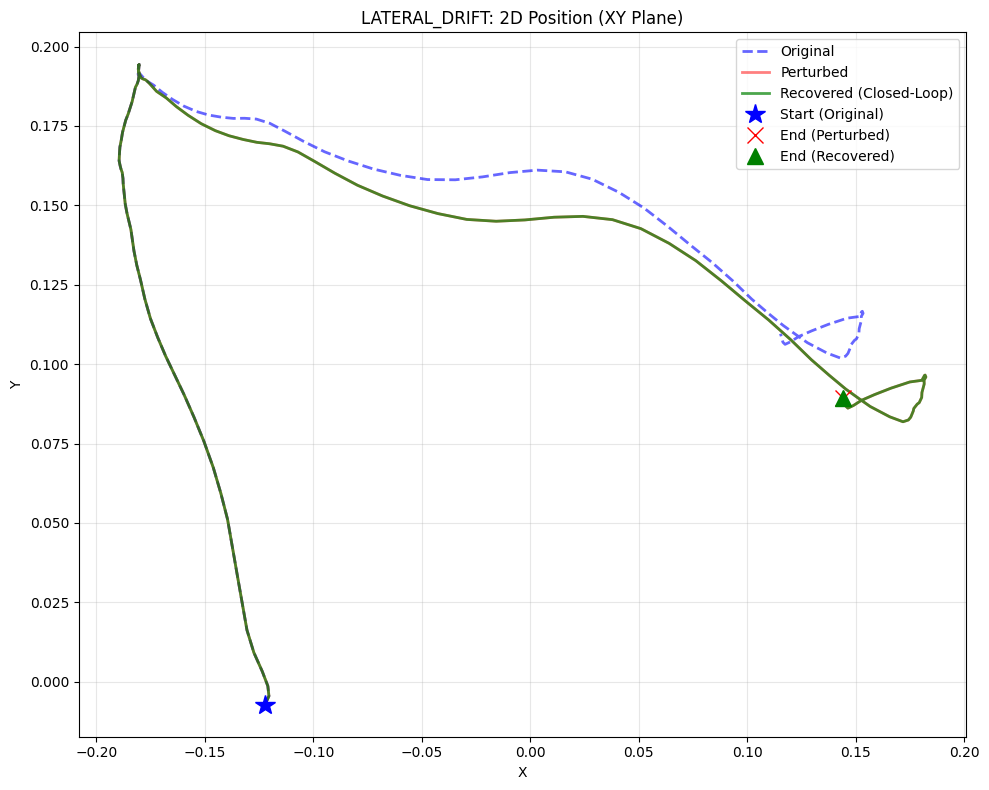

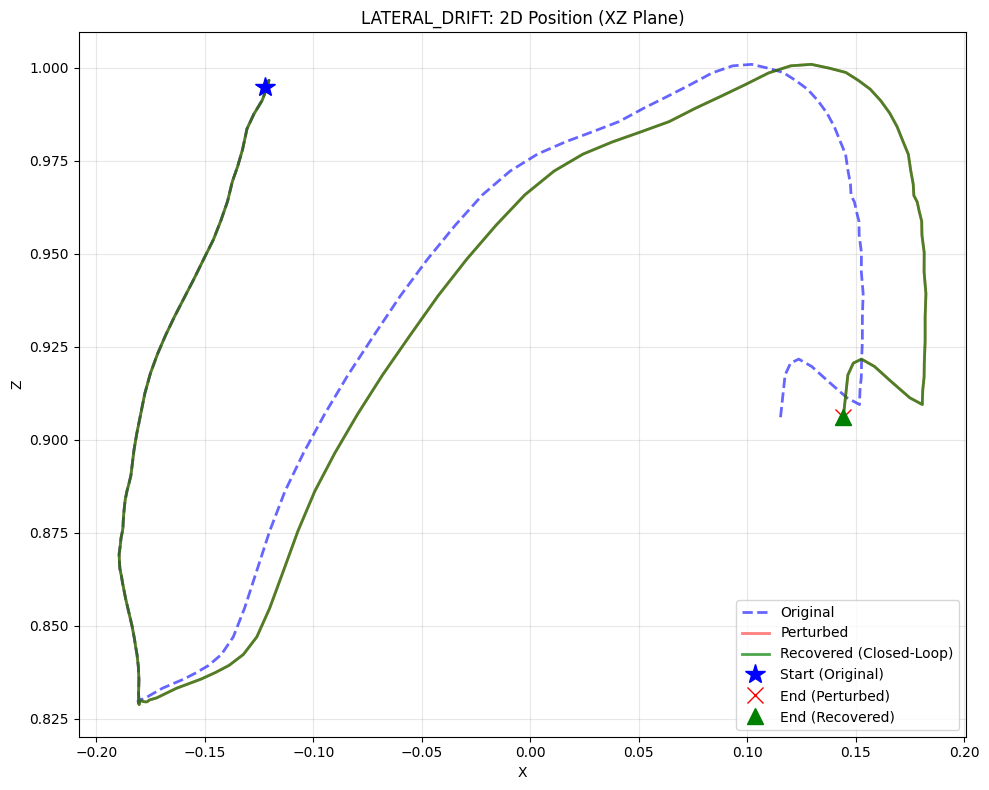

Plotting PREMATURE_OPEN...


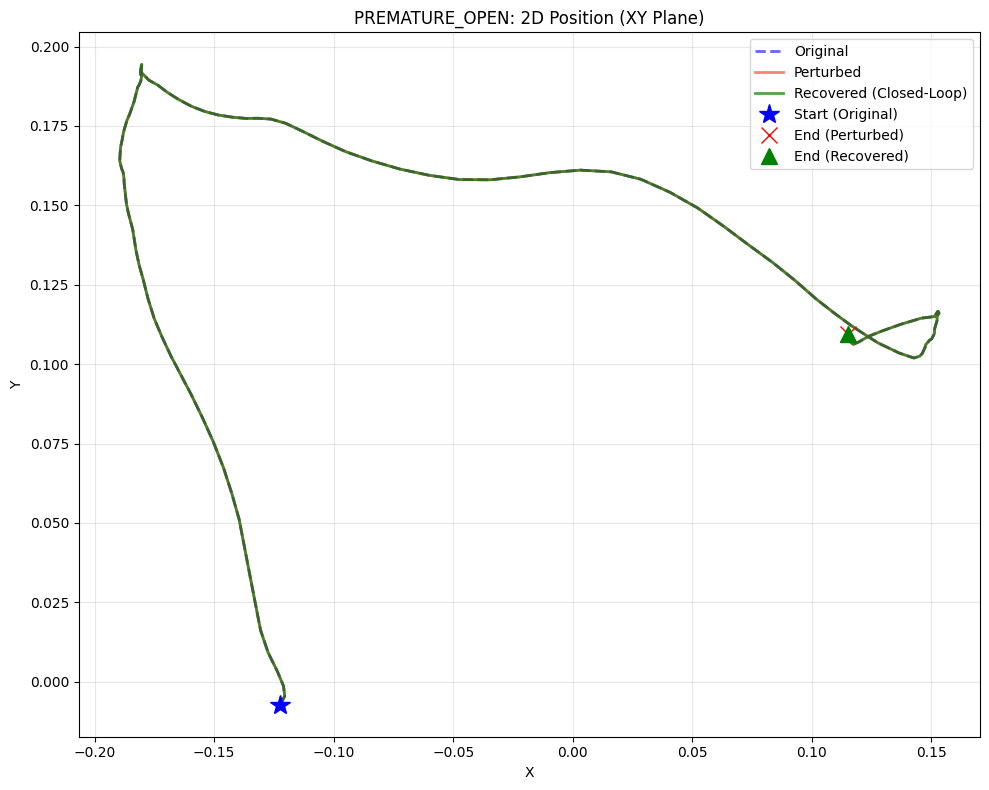

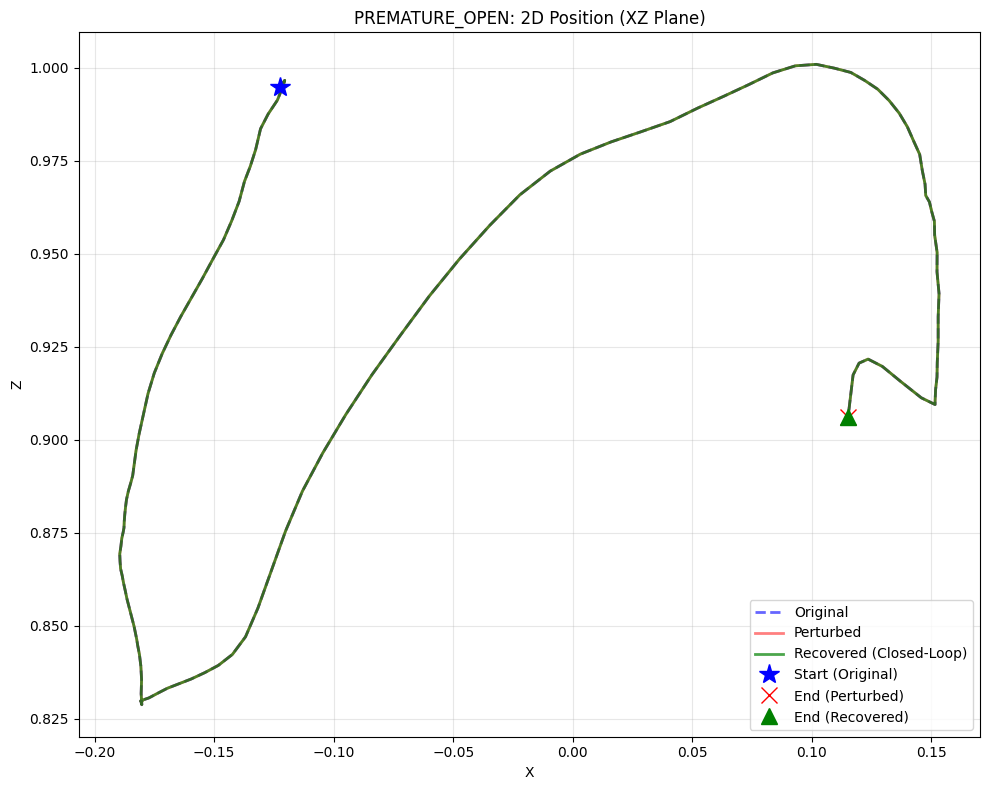

In [16]:
def plot_2d_trajectory_comparison(original, perturbed, recovered, title, plane='xy'):
    """
    Plot EE position in 2D (top-down view).
    plane: 'xy', 'xz', or 'yz'
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    orig_pos = TrajectoryAnalyzer(original).get_ee_position()
    pert_pos = TrajectoryAnalyzer(perturbed).get_ee_position()
    rec_pos = TrajectoryAnalyzer(recovered).get_ee_position()
    
    axes_map = {'xy': (0, 1), 'xz': (0, 2), 'yz': (1, 2)}
    ax_a, ax_b = axes_map[plane]
    labels = ['X', 'Y', 'Z']
    
    if len(orig_pos) > 0:
        ax.plot(orig_pos[:, ax_a], orig_pos[:, ax_b], label='Original', color='blue', alpha=0.6, linestyle='--', linewidth=2)
    if len(pert_pos) > 0:
        ax.plot(pert_pos[:, ax_a], pert_pos[:, ax_b], label='Perturbed', color='red', alpha=0.5, linewidth=2)
    if len(rec_pos) > 0:
        ax.plot(rec_pos[:, ax_a], rec_pos[:, ax_b], label='Recovered (Closed-Loop)', color='green', alpha=0.7, linewidth=2)
    
    if len(orig_pos) > 0:
        ax.plot(orig_pos[0, ax_a], orig_pos[0, ax_b], 'b*', markersize=15, label='Start (Original)')
    if len(pert_pos) > 0:
        ax.plot(pert_pos[-1, ax_a], pert_pos[-1, ax_b], 'rx', markersize=12, label='End (Perturbed)')
    if len(rec_pos) > 0:
        ax.plot(rec_pos[-1, ax_a], rec_pos[-1, ax_b], 'g^', markersize=12, label='End (Recovered)')
    
    ax.set_xlabel(labels[ax_a])
    ax.set_ylabel(labels[ax_b])
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Generate 2D plots for each perturbation type
print("\n=== 2D Trajectory Projections (Closed-Loop) ===\n")
for name, payload in vis_results_closedloop.items():
    print(f"Plotting {name}...")
    plot_2d_trajectory_comparison(
        original=orig_vis,
        perturbed=payload['perturbed'],
        recovered=payload['recovered'],
        title=f'{name}: 2D Position (XY Plane)',
        plane='xy'
    )
    plot_2d_trajectory_comparison(
        original=orig_vis,
        perturbed=payload['perturbed'],
        recovered=payload['recovered'],
        title=f'{name}: 2D Position (XZ Plane)',
        plane='xz'
    )

## Key Insights: Why Open-Loop Didn't Work

1. **Open-loop predictions diverge**: Predicting 30 steps of residuals all at once assumes the state stays constant. But after applying residuals, the state changes, making later predictions invalid.

2. **Closed-loop adapts**: By re-predicting at each step using updated state history, the policy can react and adjust.

3. **If closed-loop still shows no change**: 
   - The model may not have learned meaningful residuals (training loss might be high or converging to near-zero)
   - The data construction might be wrong (residuals in training data might be too small)
   - Consider training longer, increasing hidden dim, or revisiting the perturbation severity/timing

4. **True closed-loop requires**: Either a learned dynamics model to predict next state, or access to a simulator/environment to roll forward and observe actual state changes.

The current implementation uses the perturbed trajectory's observations, which is a compromise. For production, integrate with `robomimic`'s environment API or add a learned state predictor.

## Architecture Redesign: Dual-Policy Approach

You identified a critical issue: the residual policy is trained only on synthetic failures, but in reality you'd want:

**Current (Limited):**
- Residual policy trained: on (perturbed_state, perturbed_action_history) → residuals
- No notion of "normal" behavior to deviate from

**Proposed (Better):**
- **Base Policy**: Trained on clean, unperturbed demonstrations (original data)
  - Learns normal, collision-free behavior
  - `base_action = base_policy(state, action_history)`
- **Residual Policy**: Trained ONLY on failures (synthetic perturbations)
  - Learns: given a perturbed state+history, what residual corrects it?
  - `residual = residual_policy(perturbed_state, perturbed_action_history)`
- **At inference time**: `total_action = base_action + residual`

**Benefits:**
- Base policy handles normal task execution
- Residual policy focuses only on recovery (cleaner learning target)
- Composable and interpretable

**What You Need to Test This:**

1. **Base Policy Model** (train separately on original demos)
   - Similar to `FailureRecognizer` but outputs continuous actions
   - Or use an existing imitation learning policy from robomimic
   
2. **Evaluation Environment/Simulator**
   - Load base policy
   - Run episode in robomimic environment (or simulation)
   - At `t = perturb_start`: inject perturbation
   - Roll forward with base_action + residual_correction
   - Measure: trajectory error, task success, distance-to-original vs no-recovery baseline

3. **Data Pipeline Changes**
   - Current: `(perturbed_state, perturbed_history) → residual`
   - Updated: keep the same, but now compare base_action vs (perturbed_action + residual)
   - Or: store both base actions and residuals explicitly

4. **Metrics to Track**
   - EE position error: `|recovered_ee - original_ee|` over time
   - Success rate: Did recovery prevent task failure?
   - Convergence: How quickly does recovered trajectory re-align with original?
   - Comparison: Recovery performance vs no-correction baseline


## Pseudocode: Full Evaluation Pipeline

```python
# 1. Load trained policies
base_policy = load_base_policy('base_policy.pth')           # trained on clean demos
residual_policy = load_residual_policy('residual_recovery_policy.pth')  # trained on failures

# 2. For each test trajectory:
env = robomimic_env()  # initialize simulator
state = env.reset(demo)

state_history = deque(maxlen=HISTORY)
action_history = deque(maxlen=HISTORY)

for t in range(T):
    # a) Fill history
    state_history.append(state)
    
    # b) Base policy: normal behavior
    base_action = base_policy(state_history, action_history)
    
    # c) Inject failure at specific time
    if t == FAILURE_TIME:
        injected_perturbation = get_perturbation(PERTURB_TYPE)  # e.g., reduce position by 0.05
        state = apply_perturbation(state, injected_perturbation)
        
        # Optionally: also perturb recent action_history to reflect the failure
        # action_history[-1] = action_history[-1] + perturb_action
    
    # d) Residual correction
    residual = residual_policy(state_history, action_history)
    
    # e) Combined action
    total_action = base_action + residual  # or: clipped residual for stability
    
    # f) Step environment
    action_history.append(total_action)
    obs, info = env.step(total_action)
    state = obs
    
    # g) Track metrics
    track_ee_error(state, original_state[t])
    track_recovery_quality()

# 3. Compare baseline (no residual) vs recovered
baseline_traj = run_with_failure_and_no_recovery(env, base_policy)
recovered_traj = run_with_failure_and_residual(env, base_policy, residual_policy)

print("Baseline EE error:", compute_error(baseline_traj))
print("Recovered EE error:", compute_error(recovered_traj))
```

**Key questions to answer experimentally:**
- Does the residual policy actually correct position errors, or are they negligible?
- How sensitive is recovery to: history length, residual clipping, perturbation timing/magnitude?
- Does closed-loop (re-predict each step) recover better than open-loop?
- What's the trade-off between recovery speed and accuracy?


## Isolate Residual Policy: Test on Training Data

Without state rollout, we can't prove residuals work in closed-loop.
But we **can** test the model's learning on the data it trained on:

In [17]:
# Directly inspect what the model learned on a validation sample
print("\n=== Residual Policy Learning Test ===\n")

# Take a random validation sample
val_idx = np.random.randint(0, len(val_ds))
val_sample = val_ds[val_idx]

ps = val_sample['past_states'].float().unsqueeze(0).to(device)
pa = val_sample['past_actions'].float().unsqueeze(0).to(device)
target = val_sample['target_residuals'].float()

model.eval()
with torch.no_grad():
    pred = model(ps, pa)  # (1, HORIZON, action_dim)

pred = pred.squeeze(0).cpu().numpy()  # (HORIZON, action_dim)

print(f"Validation sample {val_idx}:")
print(f"  Target residuals shape: {target.shape}")
print(f"  Predicted residuals shape: {pred.shape}")
print(f"\n  Target (first 5 steps):\n{target[:5].numpy()}")
print(f"\n  Predicted (first 5 steps):\n{pred[:5]}")
print(f"\n  Target magnitude stats:")
print(f"    Mean: {np.mean(np.abs(target.numpy())):.6f}, Max: {np.max(np.abs(target.numpy())):.6f}")
print(f"\n  Predicted magnitude stats:")
print(f"    Mean: {np.mean(np.abs(pred)):.6f}, Max: {np.max(np.abs(pred)):.6f}")

# MSE on this sample
sample_mse = np.mean((pred - target.numpy()) ** 2)
print(f"\n  MSE on this sample: {sample_mse:.6f}")



=== Residual Policy Learning Test ===

Validation sample 38:
  Target residuals shape: torch.Size([30, 7])
  Predicted residuals shape: (30, 7)

  Target (first 5 steps):
[[ 1.1100000e-01 -3.5400000e-01  3.2100001e-01 -3.4167603e-02
   8.8589145e-03 -1.7438802e-05  1.0000000e+00]
 [ 1.2600000e-01 -2.7800000e-01  3.9199999e-01 -3.4116432e-02
   3.0769736e-02 -1.9985195e-03  1.0000000e+00]
 [ 1.0600000e-01 -3.3800000e-01  5.6099999e-01 -4.6155661e-02
   5.6526903e-02 -1.0421116e-02  1.0000000e+00]
 [ 2.1400000e-01 -2.8600001e-01  4.9500000e-01 -6.2173374e-02
   8.4286630e-02 -2.0533169e-02  1.0000000e+00]
 [ 1.3200000e-01 -3.2300001e-01  3.9199999e-01 -1.0420085e-01
   9.2399508e-02 -3.1129470e-02  1.0000000e+00]]

  Predicted (first 5 steps):
[[ 0.4614868   0.02794524  0.33914876 -0.10268079  0.0321159   0.04407359
   0.7788087 ]
 [ 0.5893846   0.04417702  0.45479038 -0.10327497  0.02140635 -0.00485109
   0.82292056]
 [ 0.68700755  0.02182331  0.5389149  -0.10223164  0.0178594  -0.0137

## Visualize Residuals as Difference Vectors

Instead of showing full trajectories (which look identical), plot:
1. **Residual magnitude over time** - does model predict non-zero residuals?
2. **Error vs Residual** - do predicted residuals align with the required correction?
3. **Vector field** - arrows showing residual direction/magnitude on 2D plane

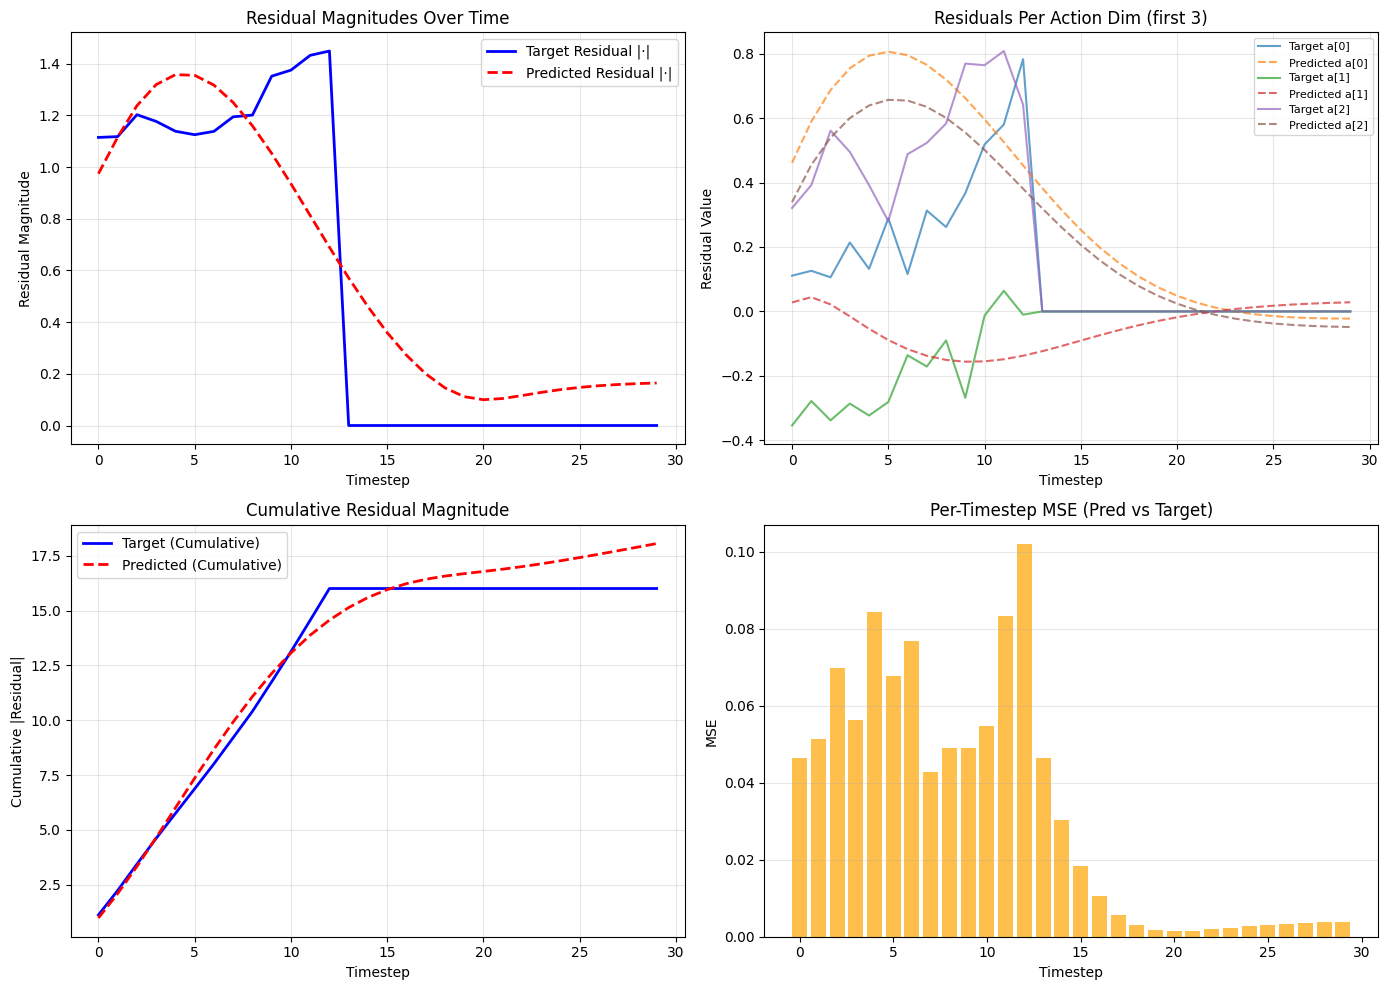


=== Residual Analysis ===
Target total L2 norm: 16.0136
Predicted total L2 norm: 18.0663
Ratio (pred/target): 1.1282

Mean per-step target magnitude: 0.533786
Mean per-step pred magnitude: 0.602211

If ratio ≈ 1.0: model learned magnitudes well
If ratio ≈ 0.0: model collapsed to zero residuals (bad training)
If ratio >> 1.0: model is over-predicting (unstable)


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residual magnitude over time
ax = axes[0, 0]
target_mag = np.linalg.norm(target.numpy(), axis=1)
pred_mag = np.linalg.norm(pred, axis=1)
t_steps = np.arange(len(target_mag))
ax.plot(t_steps, target_mag, 'b-', label='Target Residual |·|', linewidth=2)
ax.plot(t_steps, pred_mag, 'r--', label='Predicted Residual |·|', linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Residual Magnitude')
ax.set_title('Residual Magnitudes Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Per-action residual comparison (first 3 action dims)
ax = axes[0, 1]
action_dims_to_plot = min(3, action_dim)
for dim in range(action_dims_to_plot):
    ax.plot(t_steps, target[:, dim].numpy(), label=f'Target a[{dim}]', linewidth=1.5, alpha=0.7)
    ax.plot(t_steps, pred[:, dim], linestyle='--', label=f'Predicted a[{dim}]', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Timestep')
ax.set_ylabel('Residual Value')
ax.set_title(f'Residuals Per Action Dim (first {action_dims_to_plot})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Cumulative residual magnitude
ax = axes[1, 0]
target_cumsum = np.cumsum(target_mag)
pred_cumsum = np.cumsum(pred_mag)
ax.plot(t_steps, target_cumsum, 'b-', label='Target (Cumulative)', linewidth=2)
ax.plot(t_steps, pred_cumsum, 'r--', label='Predicted (Cumulative)', linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Cumulative |Residual|')
ax.set_title('Cumulative Residual Magnitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: MSE per timestep
ax = axes[1, 1]
per_step_mse = np.mean((pred - target.numpy()) ** 2, axis=1)
ax.bar(t_steps, per_step_mse, color='orange', alpha=0.7)
ax.set_xlabel('Timestep')
ax.set_ylabel('MSE')
ax.set_title('Per-Timestep MSE (Pred vs Target)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n=== Residual Analysis ===")
print(f"Target total L2 norm: {np.sum(target_mag):.4f}")
print(f"Predicted total L2 norm: {np.sum(pred_mag):.4f}")
print(f"Ratio (pred/target): {np.sum(pred_mag) / np.sum(target_mag):.4f}")
print(f"\nMean per-step target magnitude: {np.mean(target_mag):.6f}")
print(f"Mean per-step pred magnitude: {np.mean(pred_mag):.6f}")
print(f"\nIf ratio ≈ 1.0: model learned magnitudes well")
print(f"If ratio ≈ 0.0: model collapsed to zero residuals (bad training)")
print(f"If ratio >> 1.0: model is over-predicting (unstable)")

## Vector Field: Applied Residuals vs Error Correction Needed

For each perturbation type, compare:
- **Blue arrows**: What residual was applied (predicted by model)
- **Red arrows**: What residual was needed (original - perturbed actions)

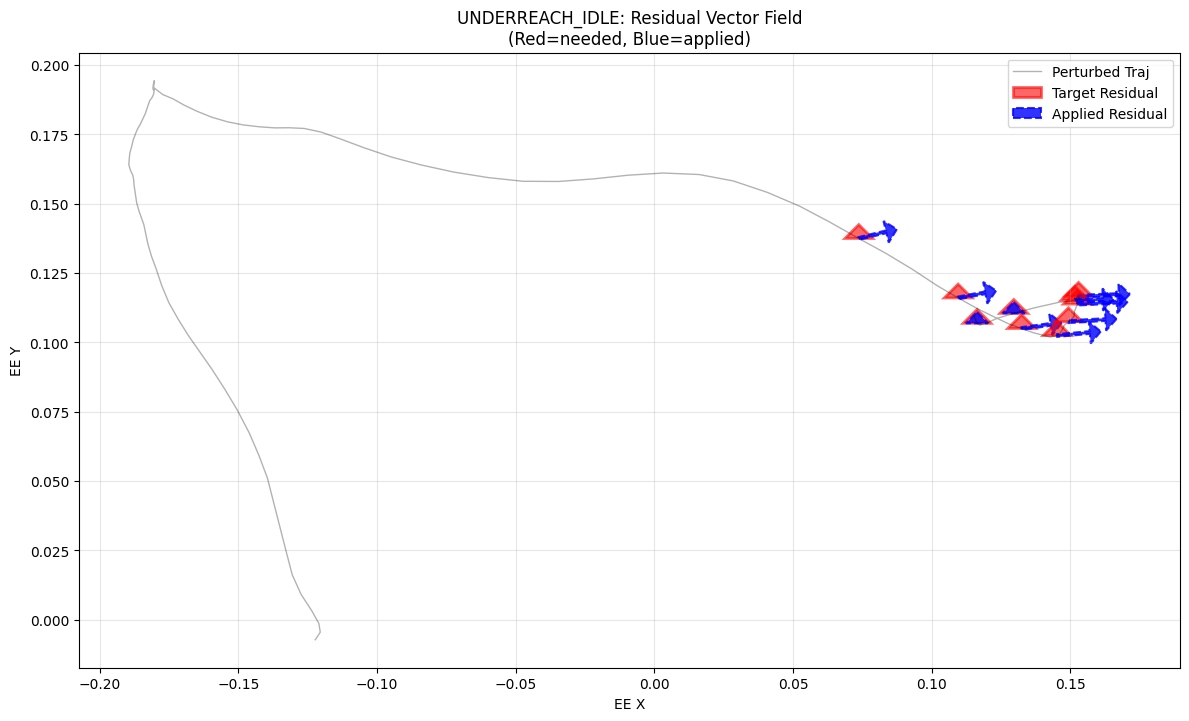


UNDERREACH_IDLE Residual Analysis:
  Target magnitude (mean): 0.000000, max: 0.000000
  Applied magnitude (mean): 0.406746, max: 0.627637
  Ratio (applied/target): inf
  Correlation (dot product): 0.000000


/home/griffing52/tmp/ipykernel_823533/1352922522.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  Ratio (applied/target): {np.mean(applied_mag) / np.mean(target_mag):.4f}")


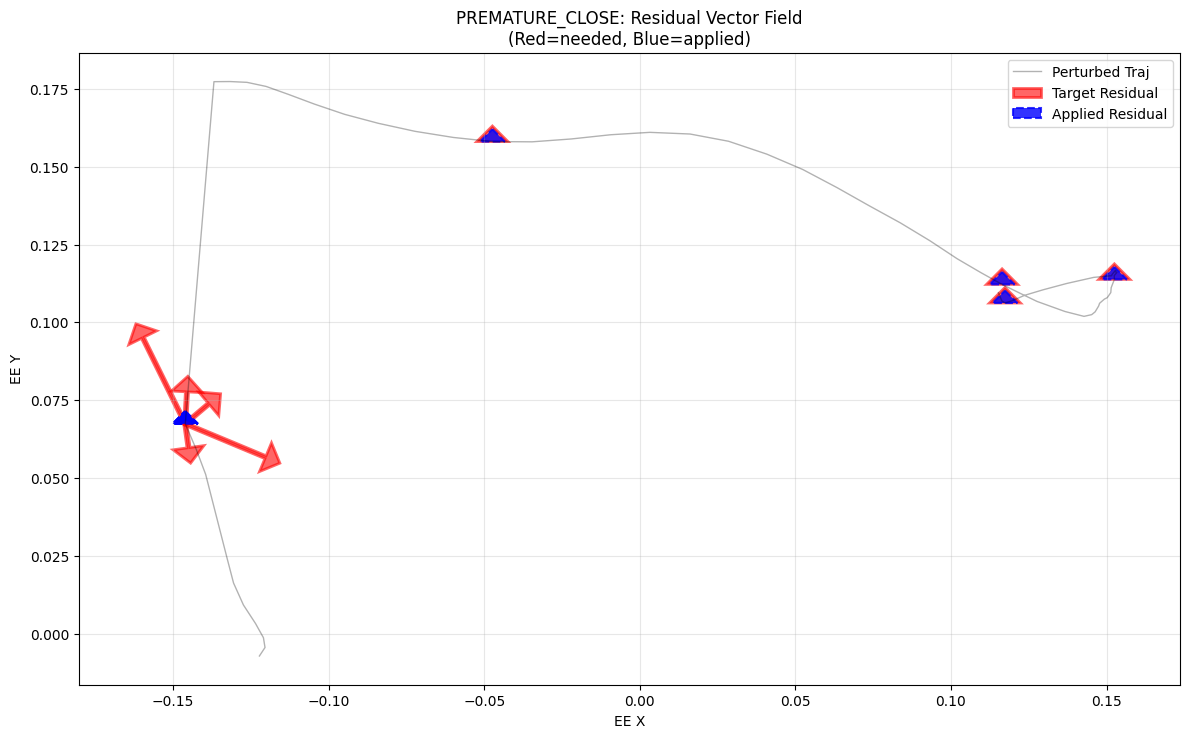


PREMATURE_CLOSE Residual Analysis:
  Target magnitude (mean): 0.574328, max: 1.250814
  Applied magnitude (mean): 0.000000, max: 0.000000
  Ratio (applied/target): 0.0000
  Correlation (dot product): 0.000000


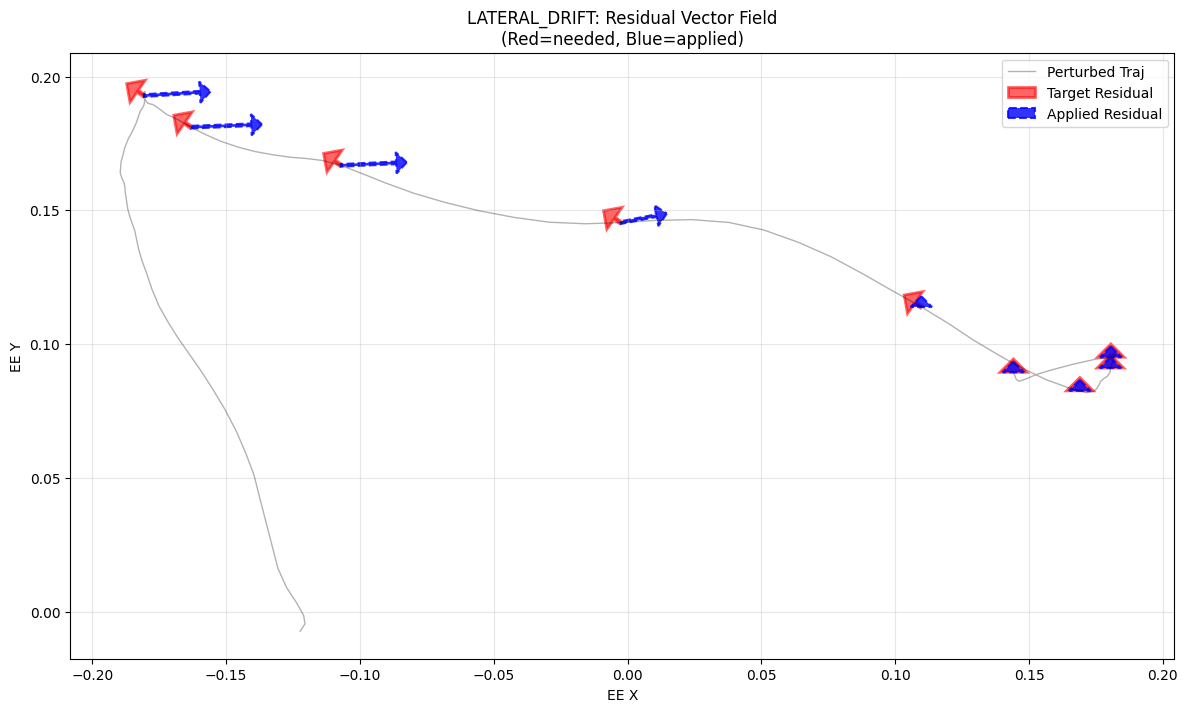


LATERAL_DRIFT Residual Analysis:
  Target magnitude (mean): 0.033186, max: 0.056340
  Applied magnitude (mean): 0.277129, max: 0.767397
  Ratio (applied/target): 8.3506
  Correlation (dot product): -0.007195


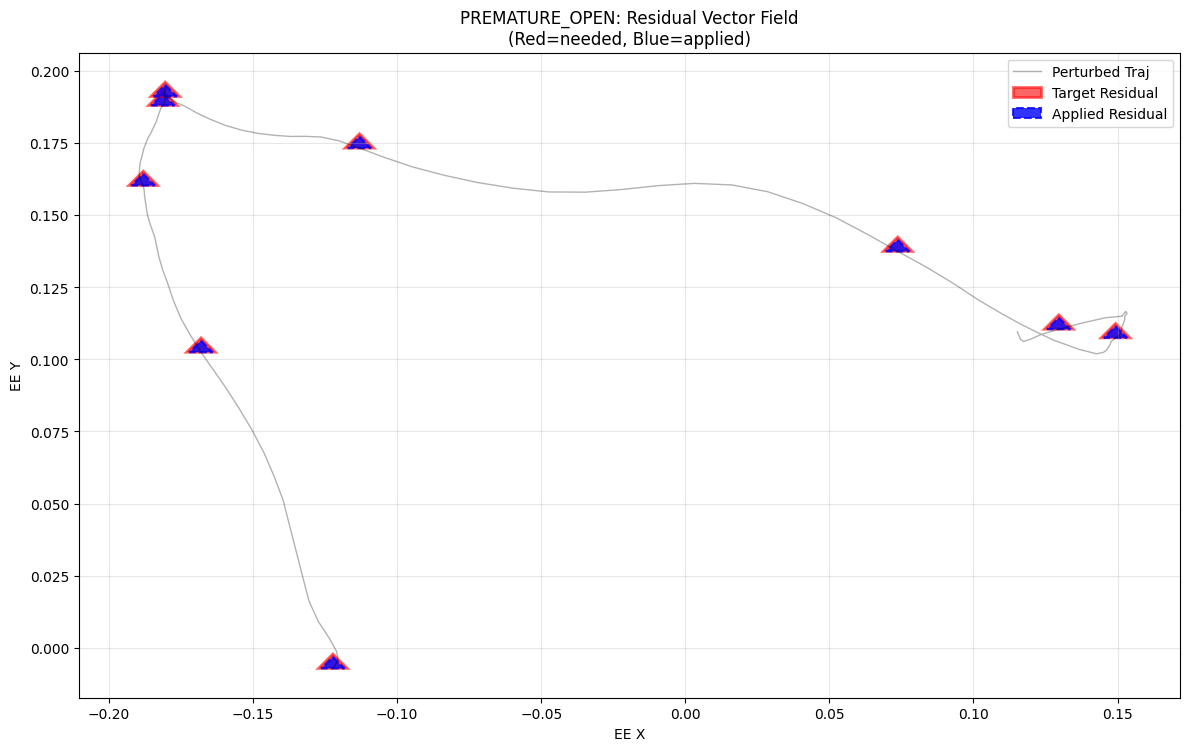


PREMATURE_OPEN Residual Analysis:
  Target magnitude (mean): 0.714042, max: 2.000000
  Applied magnitude (mean): 0.000000, max: 0.000000
  Ratio (applied/target): 0.0000
  Correlation (dot product): 0.000000


In [19]:
for name, payload in vis_results_closedloop.items():
    fig, ax = plt.subplots(figsize=(12, 8))
    
    perturbed_traj = payload['perturbed']
    applied_residuals = payload['applied_residuals']
    
    # Compute what residuals SHOULD have been (original - perturbed)
    target_residuals = []
    perturb_start, perturb_end = payload['perturbation_window']
    start = int(perturb_start)
    for t in range(start, min(start + len(applied_residuals), len(orig_vis['actions']))):
        if t < len(orig_vis['actions']) and t < len(perturbed_traj['actions']):
            orig_a = np.asarray(orig_vis['actions'][t]).reshape(-1).astype(np.float32)
            pert_a = np.asarray(perturbed_traj['actions'][t]).reshape(-1).astype(np.float32)
            target_residuals.append(orig_a - pert_a)
    
    if len(target_residuals) == 0:
        continue
    
    target_residuals = np.stack(target_residuals, axis=0)
    applied_slice = applied_residuals[start:start + len(target_residuals)]
    
    # Get EE positions to plot arrows at
    pert_pos = TrajectoryAnalyzer(perturbed_traj).get_ee_position()
    
    # Plot perturbed trajectory as background
    if len(pert_pos) > 0:
        ax.plot(pert_pos[:, 0], pert_pos[:, 1], 'k-', alpha=0.3, linewidth=1, label='Perturbed Traj')
    
    # Plot arrows for residuals (sample every N steps for clarity)
    sample_step = max(1, len(target_residuals) // 8)  # Show ~8 arrows
    
    for i in range(0, len(target_residuals), sample_step):
        if start + i < len(pert_pos):
            x, y = pert_pos[start + i, 0], pert_pos[start + i, 1]
            
            # Target (needed) residual - project to action space offset
            # For visualization, scale action residuals to spatial offset
            target_res = target_residuals[i, :2] * 0.05  # Scale for visibility
            ax.arrow(x, y, target_res[0], target_res[1], head_width=0.01, head_length=0.005, 
                    fc='red', ec='red', alpha=0.6, linewidth=2, label='Target Residual' if i == 0 else '')
            
            # Applied (predicted) residual
            applied_res = applied_slice[i, :2] * 0.05  # Same scale
            ax.arrow(x, y, applied_res[0], applied_res[1], head_width=0.008, head_length=0.004,
                    fc='blue', ec='blue', alpha=0.8, linewidth=1.5, linestyle='--', label='Applied Residual' if i == 0 else '')
    
    ax.set_xlabel('EE X')
    ax.set_ylabel('EE Y')
    ax.set_title(f'{name}: Residual Vector Field\n(Red=needed, Blue=applied)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    target_mag = np.linalg.norm(target_residuals, axis=1)
    applied_mag = np.linalg.norm(applied_slice, axis=1)
    
    print(f"\n{name} Residual Analysis:")
    print(f"  Target magnitude (mean): {np.mean(target_mag):.6f}, max: {np.max(target_mag):.6f}")
    print(f"  Applied magnitude (mean): {np.mean(applied_mag):.6f}, max: {np.max(applied_mag):.6f}")
    print(f"  Ratio (applied/target): {np.mean(applied_mag) / np.mean(target_mag):.4f}")
    print(f"  Correlation (dot product): {np.mean([np.dot(target_residuals[i], applied_slice[i]) for i in range(len(target_residuals))]):.6f}")

## Interpreting the Residual Plots

**What each plot shows:**

1. **Magnitude over time (top-left)**: Target vs Predicted residual size
   - Target: what residual was needed to correct
   - Predicted: what the model learned to output
   - **Good**: curves are similar (ratio ≈ 1.0)
   - **Bad**: predicted is flat/near-zero (model didn't learn)

2. **Per-action residuals (top-right)**: Element-wise comparison for first 3 actions
   - Each dimension should track roughly together
   - **Good**: predicted (dashed) follows target (solid)
   - **Bad**: predicted is random noise or flat

3. **Cumulative magnitude (bottom-left)**: Total correction over horizon
   - Shows whether model builds up corrections or stays inert
   - **Good**: curve grows steadily
   - **Bad**: flat line (no learning)

4. **Per-step MSE (bottom-right)**: Error between target and predicted
   - **Good**: starts higher, decreases as training progressed
   - **Bad**: consistently high or random

5. **Vector field (separate plot)**: Red arrows = needed, Blue arrows = applied
   - **Good**: Blue arrows point in same direction as Red (aligned)
   - **Bad**: Blue arrows point away, or are much smaller, or random
   - **Excellent**: Red and Blue arrows overlap

**Summary metrics to watch:**
- `Ratio (pred/target)`: should be close to 1.0
- `Correlation`: should be positive (arrows point same direction)
- If both near zero, model learned but residuals are very small (may not be useful)
- If pred >> target, model is unstable (over-correcting)